## Purpose
The purpose of this notebook is to examine the distribution of methylation pairs(gbM-teM, gbM-uM, and teM-uM) across different duplication modes (WGD, syntenic secondary duplication, non-syntenic WGD, tandem, proximal, dispersed, and transposed. 

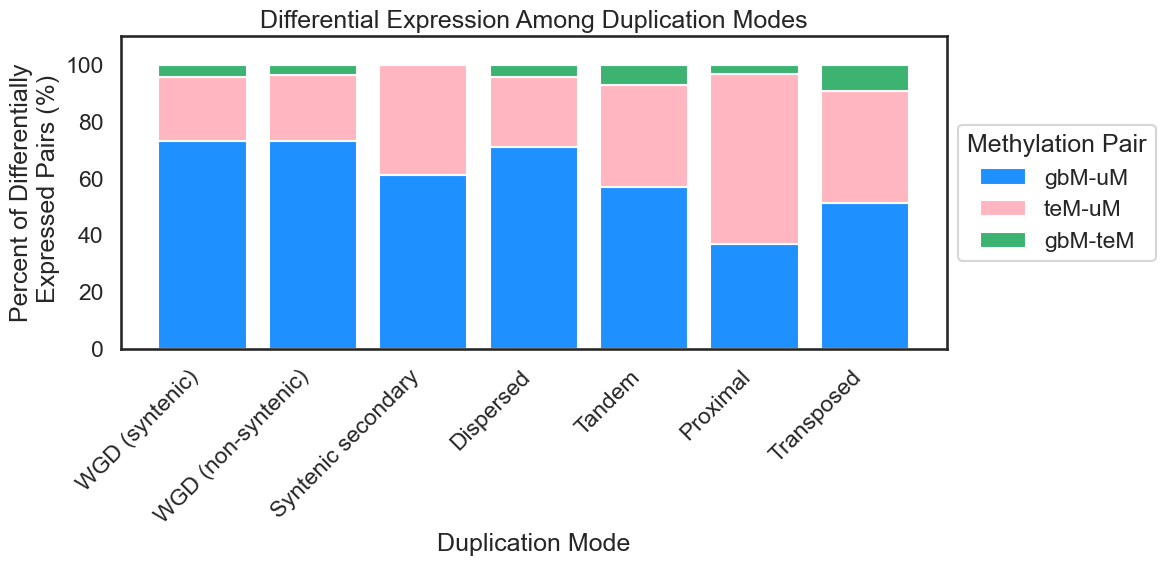

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white", context="talk")


data = {
    "DuplicationMode": [
        "WGD (syntenic)", "WGD (syntenic)", "WGD (syntenic)",
        "WGD (non-syntenic)", "WGD (non-syntenic)", "WGD (non-syntenic)",
        "Syntenic secondary", "Syntenic secondary", "Syntenic secondary",
        "Dispersed", "Dispersed", "Dispersed",
        "Tandem", "Tandem", "Tandem",
        "Proximal", "Proximal", "Proximal",
        "Transposed", "Transposed", "Transposed"
    ],
    "MethylationPair": [
        "gbM-uM", "teM-uM", "gbM-teM",
        "gbM-uM", "teM-uM", "gbM-teM",
        "gbM-uM", "teM-uM", "gbM-teM",
        "gbM-uM", "teM-uM", "gbM-teM",
        "gbM-uM", "teM-uM", "gbM-teM",
        "gbM-uM", "teM-uM", "gbM-teM",
        "gbM-uM", "teM-uM", "gbM-teM"
    ],
    "DiffExpPairs": [
        256, 78, 15,
        189, 60, 9,
        27, 17, 0,
        1286, 446, 77,
        16, 10, 2,
        36, 58, 3,
        170, 130, 30
    ]
}

df = pd.DataFrame(data)

# Percentage per duplication mode
df["Percent"] = df.groupby("DuplicationMode")["DiffExpPairs"].transform(lambda x: 100 * x / x.sum())

#plot
colors = {"gbM-uM": "dodgerblue", "teM-uM": "lightpink", "gbM-teM": "mediumseagreen"}

plt.figure(figsize=(12,6))
dup_modes = df["DuplicationMode"].unique()
bottom_values = [0]*len(dup_modes)

for pair in ["gbM-uM", "teM-uM", "gbM-teM"]:
    values = df[df["MethylationPair"]==pair]["Percent"].values
    plt.bar(dup_modes, values, bottom=bottom_values, color=colors[pair], label=pair)
    bottom_values = [i+j for i,j in zip(bottom_values, values)]

plt.ylabel("Percent of Differentially\n Expressed Pairs (%)")
plt.xlabel("Duplication Mode")
plt.title("Differential Expression Among Duplication Modes")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)
plt.legend(title="Methylation Pair", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("diff_exp_duplModes", dpi=300, bbox_inches='tight')
plt.show()